# Predicting House Prices

In [2]:
# The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv

In [3]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

In [4]:
base_data = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv"

In [5]:
housing_p = pd.read_csv(base_data)
housing_p

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


## exploratory data analysis


In [6]:
housing_p.tail(10)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2627,907135040,20,RL,112.0,10859,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,145000
2628,907280040,60,RL,75.0,9375,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,240000
2629,909252170,70,RL,53.0,6720,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2007,CWD,Normal,141500
2630,534401130,80,RL,82.0,9020,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,5,2008,WD,Normal,174900
2631,535457020,20,RL,80.0,8000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,11,2007,WD,Normal,156500
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000
2636,528292060,60,RL,41.0,12460,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,225000


In [7]:
housing_p.sort_values(by ="SalePrice")

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
37,902207130,30,RM,68.0,9656,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Abnorml,12789
372,910251050,20,A (agr),80.0,14584,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Abnorml,13100
602,902477120,30,C (all),60.0,7879,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900
29,909101330,30,RL,60.0,8088,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,ConLD,Normal,35000
1593,911175430,20,C (all),50.0,9000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,Abnorml,35311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,528110020,20,RL,105.0,13693,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Normal,610000
2163,528150070,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
1868,528164060,20,RL,106.0,12720,Pave,NaN,Reg,HLS,AllPub,...,144,Ex,NaN,NaN,0,2,2008,WD,Normal,615000
2546,528320060,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000


In [8]:
with pd.option_context('display.max_columns', 82):
    display(housing_p.head())

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,Norm,1Fam,1Story,4,3,1964,1964,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,513.0,LwQ,144.0,348.0,1005.0,GasA,TA,Y,SBrkr,1005,0,0,1005,1.0,0.0,1,0,3,1,TA,5,Typ,0,NaN,Detchd,1964.0,Unf,2.0,440.0,TA,TA,N,0,0,0,0,0,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,Duplex,1Story,4,5,1967,1967,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,Slab,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,GasA,TA,Y,SBrkr,1296,0,0,1296,0.0,0.0,2,0,2,2,TA,6,Typ,0,NaN,CarPort,1967.0,Unf,2.0,516.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,1.5Fin,6,6,1937,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,Gd,PConc,TA,TA,No,Unf,0.0,Unf,0.0,780.0,780.0,GasA,TA,Y,SBrkr,780,595,0,1375,0.0,0.0,1,1,3,1,Gd,6,Typ,1,Gd,Detchd,1979.0,Unf,1.0,544.0,TA,TA,P,0,162,0,0,126,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,GLQ,484.0,Unf,0.0,491.0,975.0,GasA,Ex,Y,SBrkr,975,873,0,1848,1.0,0.0,2,1,3,1,Gd,7,Typ,1,TA,Attchd,2000.0,RFn,2.0,592.0,TA,TA,Y,280,184,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Feedr,Norm,1Fam,2Story,7,9,1936,2007,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,Gd,Gd,PConc,Gd,Gd,No,ALQ,350.0,BLQ,210.0,0.0,560.0,GasA,Ex,Y,SBrkr,575,560,0,1135,1.0,0.0,1,0,3,1,Gd,6,Typ,0,NaN,Detchd,1971.0,RFn,2.0,576.0,TA,TA,Y,256,0,0,0,0,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [9]:
housing_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [10]:
housing_p.dtypes.value_counts()

,count
object,43
int64,27
float64,11


In [11]:
nunique = housing_p.nunique().sort_values( ascending = False )
nunique

,0
PID,2637
Lot Area,1799
Gr Liv Area,1216
Bsmt Unf SF,1080
1st Flr SF,1022
...,...
Bsmt Half Bath,3
Paved Drive,3
Street,2
Alley,2


In [12]:
pd.set_option('display.max_rows', 10)

In [13]:
housing_p.select_dtypes(include = ["int64"])

,PID,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,905101070,20,14299,4,3,1964,1964,1005,0,0,...,0,0,0,0,0,0,0,7,2007,115400
1,905101330,90,10791,4,5,1967,1967,1296,0,0,...,0,0,0,0,0,0,500,10,2006,90000
2,903454090,50,9000,6,6,1937,1950,780,595,0,...,0,162,0,0,126,0,0,12,2007,141000
3,533244030,60,7379,8,5,2000,2000,975,873,0,...,280,184,0,0,0,0,0,4,2010,254000
4,909252020,70,7200,7,9,1936,2007,575,560,0,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,6240,6,6,1934,1950,816,0,360,...,112,0,0,0,0,0,400,9,2006,114500
2633,906201021,80,10778,7,6,1990,1991,1061,0,0,...,114,36,0,0,0,0,0,7,2009,162000
2634,533253070,120,3782,8,5,1981,1981,1226,0,0,...,133,78,0,0,0,0,0,9,2009,211500
2635,527376100,20,10140,6,5,1974,1974,1350,0,0,...,0,0,0,0,0,0,0,8,2009,165000


In [14]:
housing_p.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.637000e+03,2637.000000,2188.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2614.000000,2636.000000,...,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000,2637.000000
mean,7.141301e+08,57.349261,69.166819,10044.694729,6.097459,5.569966,1971.288586,1984.202882,101.887911,438.441199,...,94.305271,46.984452,22.813424,2.368601,15.775123,2.130072,42.014031,6.243838,2007.795601,179986.230186
std,1.887527e+08,42.499091,23.356779,6742.549521,1.411522,1.118262,30.306986,20.913077,179.578232,449.602326,...,126.927272,66.564333,61.177638,23.160600,55.783751,35.140140,393.158781,2.722093,1.306403,78309.251522
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7436.000000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354530e+08,50.000000,68.000000,9450.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071870e+08,70.000000,80.000000,11526.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,732.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213000.000000
max,1.007100e+09,190.000000,313.000000,164660.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,584.000000,407.000000,576.000000,800.000000,12500.000000,12.000000,2010.000000,745000.000000


In [55]:
housing_p.isnull().sum().sum()

np.int64(14208)

In [15]:
housing_p.isnull().sum().sort_values( ascending = False )

,0
Pool QC,2626
Misc Feature,2541
Alley,2457
Fence,2109
Mas Vnr Type,1607
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [16]:
housing_p_lr = housing_p[['SalePrice', 'Lot Area']]
housing_p_lr

,SalePrice,Lot Area
0,115400,14299
1,90000,10791
2,141000,9000
3,254000,7379
4,155000,7200
...,...,...
2632,114500,6240
2633,162000,10778
2634,211500,3782
2635,165000,10140


In [17]:
# the items have no significance in the price many cells are empty
housing_p_fence = housing_p[['SalePrice', 'Fence', 'Misc Feature', 'Alley', 'Pool QC']]
housing_p_fence.head(10).sort_values( 'SalePrice', ascending = False )

,SalePrice,Fence,Misc Feature,Alley,Pool QC
3,254000,NaN,NaN,NaN,NaN
8,235000,NaN,NaN,NaN,NaN
6,194500,NaN,NaN,NaN,NaN
7,185000,NaN,NaN,NaN,NaN
4,155000,MnPrv,NaN,NaN,NaN
9,152000,NaN,NaN,Pave,NaN
2,141000,NaN,NaN,NaN,NaN
5,125000,MnPrv,NaN,NaN,NaN
0,115400,MnPrv,NaN,NaN,NaN
1,90000,NaN,Shed,NaN,NaN


In [18]:
drop_ids = nunique[ nunique == housing_p.shape[0] ].index
drop_ids

Index(['PID'], dtype='object')

In [19]:
housing_p['SalePrice'].isnull().sum()

np.int64(0)

In [20]:
housing_p.isnull().sum().sum()

np.int64(14208)

## Cleaning

In [21]:
housing_p_c = housing_p.copy()

In [22]:
# getting rid of the rows that have nulls
housing_p_c.drop(columns = ["PID", 'Fence', 'Misc Feature', 'Alley', 'Pool QC', 'Mas Vnr Type', 'Fireplace Qu', 'Lot Frontage', 'Garage Yr Blt', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Garage Type', 'Bsmt Exposure', 'BsmtFin Type 2'],inplace = True)

In [23]:
housing_p_c.drop(columns = ['Bsmt Qual', 'BsmtFin Type 1', 'Bsmt Cond', 'Mas Vnr Area', 'Bsmt Half Bath', 'Bsmt Full Bath', 'Garage Cars', 'Garage Area',],inplace = True)

In [24]:
housing_p_c.drop(columns = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF'], inplace = True)

In [25]:
housing_p_c = housing_p_c.select_dtypes(exclude=['object'])

In [26]:
#dropped row from 81 to 26
housing_p_c.shape

(2637, 26)

In [27]:
housing_p_c.isnull().sum().sort_values( ascending = False ).head(10)

,0
MS SubClass,0
Lot Area,0
Overall Qual,0
Overall Cond,0
Year Built,0
Year Remod/Add,0
1st Flr SF,0
2nd Flr SF,0
Low Qual Fin SF,0
Gr Liv Area,0


In [28]:
housing_p_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   MS SubClass      2637 non-null   int64
 1   Lot Area         2637 non-null   int64
 2   Overall Qual     2637 non-null   int64
 3   Overall Cond     2637 non-null   int64
 4   Year Built       2637 non-null   int64
 5   Year Remod/Add   2637 non-null   int64
 6   1st Flr SF       2637 non-null   int64
 7   2nd Flr SF       2637 non-null   int64
 8   Low Qual Fin SF  2637 non-null   int64
 9   Gr Liv Area      2637 non-null   int64
 10  Full Bath        2637 non-null   int64
 11  Half Bath        2637 non-null   int64
 12  Bedroom AbvGr    2637 non-null   int64
 13  Kitchen AbvGr    2637 non-null   int64
 14  TotRms AbvGrd    2637 non-null   int64
 15  Fireplaces       2637 non-null   int64
 16  Wood Deck SF     2637 non-null   int64
 17  Open Porch SF    2637 non-null   int64
 18  Enclosed

In [29]:
housing_p_c.sort_values( by = ['SalePrice'] , ascending = False)

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
2494,60,15623,10,5,1996,1996,2411,2065,0,4476,...,171,78,0,0,0,555,0,7,2007,745000
2546,60,35760,10,5,1995,1996,1831,1796,0,3627,...,361,76,0,0,0,0,0,7,2006,625000
1868,20,12720,10,5,2003,2003,2470,0,0,2470,...,154,65,0,0,216,144,0,2,2008,615000
2163,20,12919,9,5,2009,2010,2364,0,0,2364,...,0,67,0,0,0,0,0,3,2010,611657
323,20,13693,10,5,2007,2007,2674,0,0,2674,...,360,50,0,0,0,0,0,3,2009,610000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1593,20,9000,2,3,1949,1950,480,0,0,480,...,0,0,0,0,0,0,0,10,2006,35311
29,30,8088,2,3,1922,1955,498,0,0,498,...,0,0,100,0,0,0,0,2,2006,35000
602,30,7879,4,5,1920,1950,720,0,0,720,...,0,523,115,0,0,0,0,11,2009,34900
372,20,14584,1,5,1952,1952,733,0,0,733,...,0,0,0,0,0,0,0,2,2008,13100


In [30]:
housing_p_c.shape


(2637, 26)

In [31]:
#have to turn all strings to int64 so better understand info

In [32]:
housing_p_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   MS SubClass      2637 non-null   int64
 1   Lot Area         2637 non-null   int64
 2   Overall Qual     2637 non-null   int64
 3   Overall Cond     2637 non-null   int64
 4   Year Built       2637 non-null   int64
 5   Year Remod/Add   2637 non-null   int64
 6   1st Flr SF       2637 non-null   int64
 7   2nd Flr SF       2637 non-null   int64
 8   Low Qual Fin SF  2637 non-null   int64
 9   Gr Liv Area      2637 non-null   int64
 10  Full Bath        2637 non-null   int64
 11  Half Bath        2637 non-null   int64
 12  Bedroom AbvGr    2637 non-null   int64
 13  Kitchen AbvGr    2637 non-null   int64
 14  TotRms AbvGrd    2637 non-null   int64
 15  Fireplaces       2637 non-null   int64
 16  Wood Deck SF     2637 non-null   int64
 17  Open Porch SF    2637 non-null   int64
 18  Enclosed

In [33]:
housing_p_c.select_dtypes(include=['int64', 'float64'])


,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,7,2007,115400
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,500,10,2006,90000
2,50,9000,6,6,1937,1950,780,595,0,1375,...,0,162,0,0,126,0,0,12,2007,141000
3,60,7379,8,5,2000,2000,975,873,0,1848,...,280,184,0,0,0,0,0,4,2010,254000
4,70,7200,7,9,1936,2007,575,560,0,1135,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,112,0,0,0,0,0,400,9,2006,114500
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,114,36,0,0,0,0,0,7,2009,162000
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,133,78,0,0,0,0,0,9,2009,211500
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,0,0,0,0,0,0,0,8,2009,165000


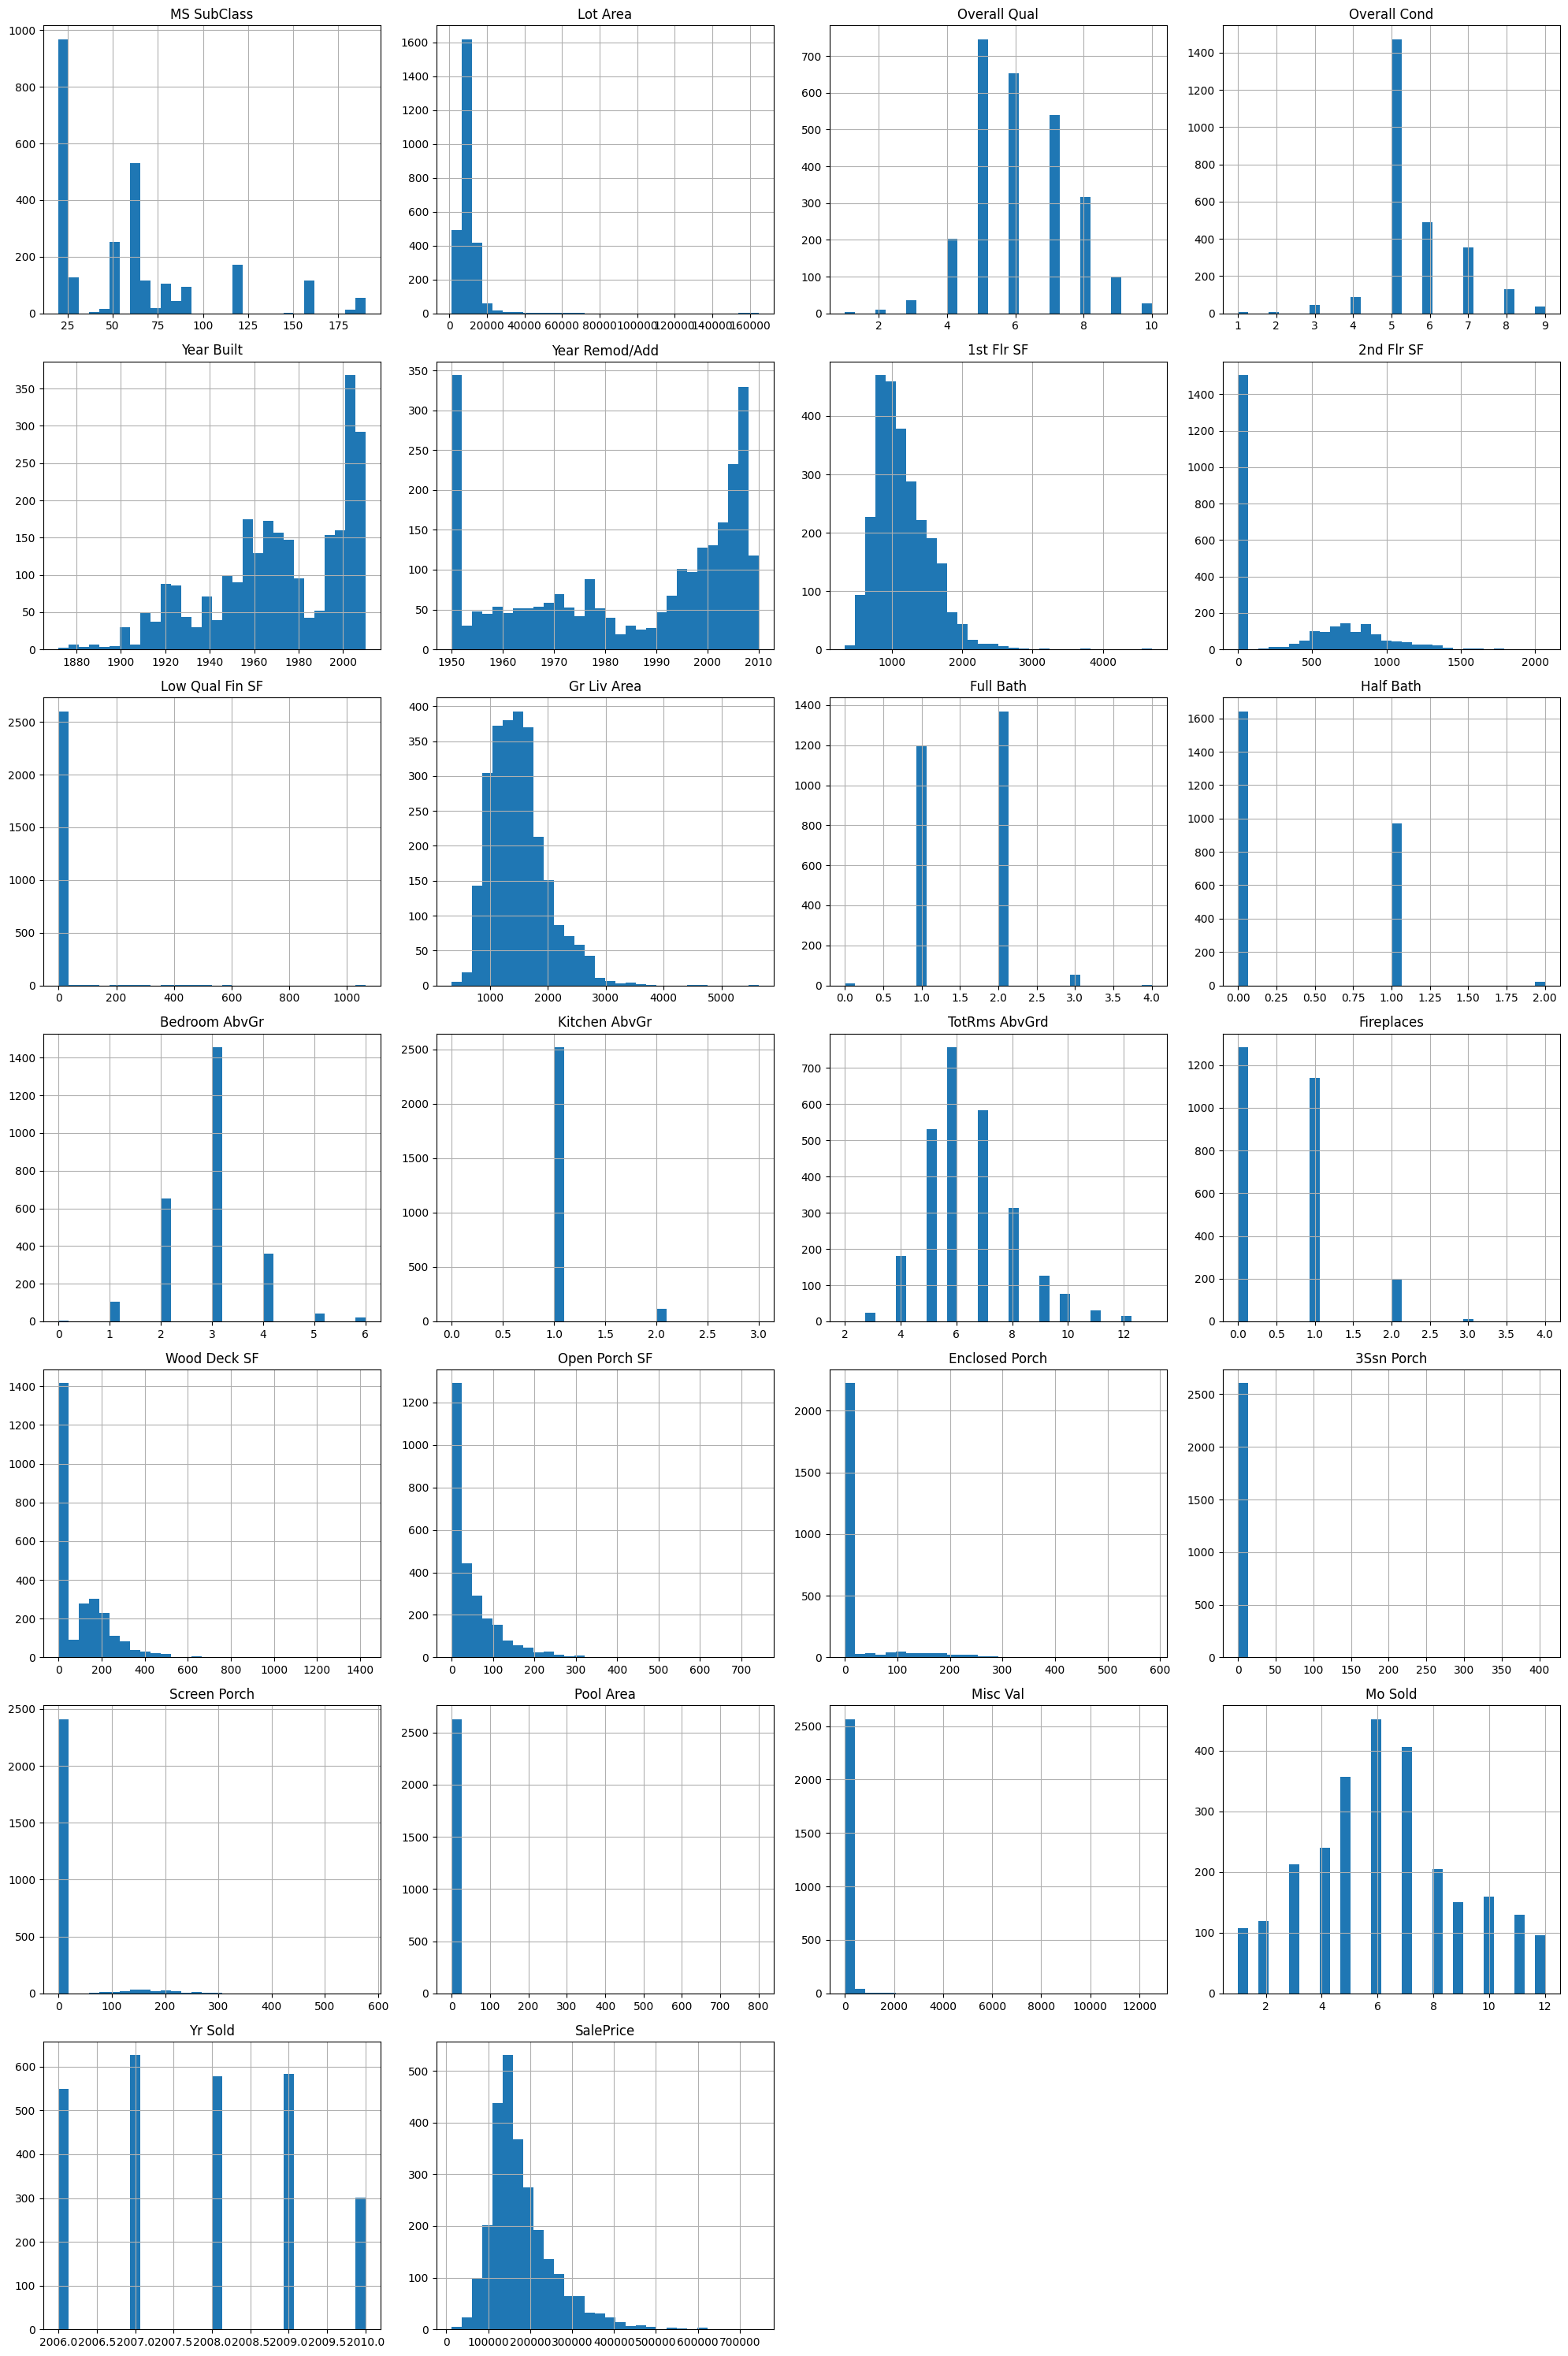

In [57]:
 # 1. Grab only the numbers
numerical_cols = housing_p_c.select_dtypes(include=['int64', 'float64'])

# 2. Plot all histograms automatically
# (figsize width=20, height=30 gives them plenty of room to breathe)
numerical_cols.hist(figsize=(20, 30), bins=30, layout=(-1, 4))

plt.tight_layout()
plt.show()

In [35]:
#sns.pairplot(housing_p_c) ;

In [36]:
 #corr_matrix = housing_p.corr()
#corr

In [37]:
corr_matrix = housing_p_c.corr(numeric_only=True)
corr_matrix

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
MS SubClass,1.000000,-0.220406,0.046362,-0.069494,0.036241,0.042770,-0.249497,0.303093,0.016494,0.070539,...,-0.016255,-0.011079,-0.027317,-0.035452,-0.048090,-0.005281,-0.016237,-0.006331,-0.015536,-0.078857
Lot Area,-0.220406,1.000000,0.095071,-0.029723,0.030558,0.032820,0.347911,0.049998,-0.002348,0.311768,...,0.180943,0.118606,0.017355,0.022052,0.053741,0.101980,0.053556,0.015153,-0.027787,0.268516
Overall Qual,0.046362,0.095071,1.000000,-0.089281,0.595225,0.571035,0.467009,0.244258,-0.057611,0.566552,...,0.245627,0.295126,-0.153659,0.013418,0.028213,0.026957,-0.036647,0.042192,-0.020052,0.805016
Overall Cond,-0.069494,-0.029723,-0.089281,1.000000,-0.359411,0.048439,-0.151234,0.002867,0.004491,-0.113959,...,0.030796,-0.068209,0.079232,0.045597,0.053407,-0.009012,0.030705,-0.009906,0.042123,-0.095205
Year Built,0.036241,0.030558,0.595225,-0.359411,1.000000,0.614758,0.298960,0.022109,-0.139847,0.237357,...,0.220759,0.186176,-0.387146,0.013311,-0.056855,0.010353,-0.032083,0.014814,-0.014875,0.562777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pool Area,-0.005281,0.101980,0.026957,-0.009012,0.010353,-0.014081,0.138882,0.032547,-0.006026,0.134865,...,0.112868,0.065687,-0.015813,-0.006202,0.033065,1.000000,0.022022,-0.037580,-0.049366,0.072427
Misc Val,-0.016237,0.053556,-0.036647,0.030705,-0.032083,-0.034232,-0.008271,0.018596,-0.007538,0.008987,...,0.041788,0.028382,0.028277,0.003782,0.022360,0.022022,1.000000,0.000197,0.027787,-0.019955
Mo Sold,-0.006331,0.015153,0.042192,-0.009906,0.014814,0.023667,0.045737,0.018123,0.009026,0.051811,...,0.011790,0.038141,-0.009985,0.038083,0.028270,-0.037580,0.000197,1.000000,-0.160078,0.052800
Yr Sold,-0.015536,-0.027787,-0.020052,0.042123,-0.014875,0.035704,-0.009183,-0.014703,0.002094,-0.019604,...,0.010937,-0.033148,0.013231,0.012258,-0.009480,-0.049366,0.027787,-0.160078,1.000000,-0.030053


In [38]:
corr_matrix['SalePrice'].sort_values(ascending=False).head(10)

,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932
TotRms AbvGrd,0.493853
Fireplaces,0.468886
Wood Deck SF,0.322060


In [39]:
corr_matrix['SalePrice'].sort_values(ascending=False).tail(10)

,SalePrice
Pool Area,0.072427
Mo Sold,0.052800
3Ssn Porch,0.040625
Misc Val,-0.019955
Yr Sold,-0.030053
Low Qual Fin SF,-0.040838
MS SubClass,-0.078857
Overall Cond,-0.095205
Kitchen AbvGr,-0.122953
Enclosed Porch,-0.141685


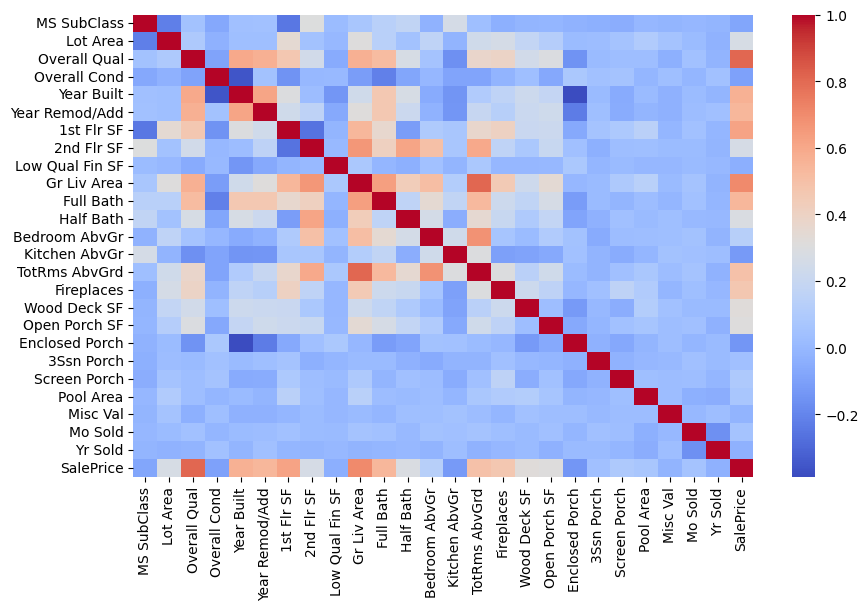

In [58]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)  # annot=False keeps it from being a crowded mess
plt.show()

In [41]:
#housing_p_c.select_dtypes(include=['int64', 'float64'])

In [42]:
#corrs = housing_p_c.select_dtypes(include=['int64', 'float64']).corr().round(2).unstack().abs()
corrs = housing_p_c.corr().round(2).unstack().abs()
corrs = corrs[corrs < 1]
corrs.sort_values(ascending = False).head(20)[::2]

TotRms AbvGrd   Gr Liv Area      0.81
Gr Liv Area     TotRms AbvGrd    0.81
                SalePrice        0.71
Bedroom AbvGr   TotRms AbvGrd    0.68
Gr Liv Area     2nd Flr SF       0.66
Full Bath       Gr Liv Area      0.63
SalePrice       1st Flr SF       0.62
2nd Flr SF      Half Bath        0.61
Year Remod/Add  Year Built       0.61
TotRms AbvGrd   2nd Flr SF       0.60
dtype: float64

In [43]:
#sns.pairplot(housing_p_c) ;

In [44]:
#once correclation matrix heat map done. move forward to the linear regression graph
# 2. Seperate feutures x = housing_p_lr.drop(['SalesPrice'])
#X = housing_p_c.drop(columns=['SalePrice'])
#y = housing_p_c['SalePrice']
#X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)


In [45]:
X = housing_p_c[['Gr Liv Area', '1st Flr SF']]
X2 = sm.add_constant(X) # add constant so that intercept is estimated
print(X2.head())

y = housing_p_c['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size = 0.2, random_state=4)

   const  Gr Liv Area  1st Flr SF
0    1.0         1005        1005
1    1.0         1296        1296
2    1.0         1375         780
3    1.0         1848         975
4    1.0         1135         575


In [46]:
X = housing_p_c[['Gr Liv Area', '1st Flr SF', '2nd Flr SF','Half Bath','Year Built','Overall Qual']]
y = housing_p_c['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=4)

In [47]:
model = LinearRegression()
myfit2 = model.fit(X_train, y_train)

( myfit2.intercept_, myfit2.coef_ )


(np.float64(-934079.6685920751),
 array([2.99817460e+01, 5.72639560e+01, 1.82678456e+01, 1.96626579e+03,
        4.29202453e+02, 2.45278521e+04]))

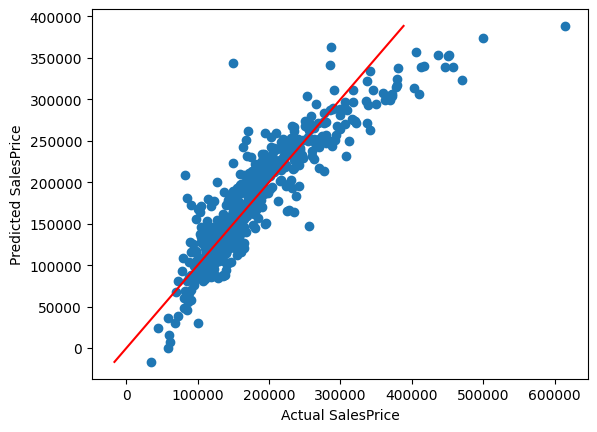

In [48]:
y_pred = myfit2.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='red')
plt.xlabel('Actual SalesPrice')
plt.ylabel('Predicted SalesPrice') ;

In [49]:
rmse = mean_squared_error(y_test, y_pred)**0.5
print(f"RMSE: {rmse}")

RMSE: 35869.630318180745


In [50]:
#RMSE - 50258.24 ('Gr Liv Area', '1st Flr SF')
# 49588.86 ( + 2nd Flr SF)
# 48295.83 ( + 'Half Bath )
# 41274.23 ( + Year Built)
# 35869.63 ( + Overall Qual)

In [51]:
results = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 36035.526552766685


In [ ]:
#CV RMSE - 51020.20('Gr Liv Area', '1st Flr SF')
#CV RMSE - 50639.64 ( + 2nd Flr SF)
#CV RMSE - 49910.37 ( + 'Half Bath )
#CV RMSE - 42628.91 ( + Year Built)
#CV RMSE - 36035.52 ( + Overall Qual)

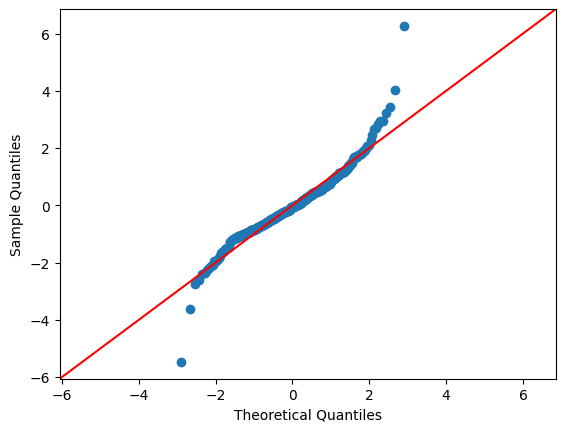

In [52]:
#play around with different ways to make since of the data
#try the QQ plot
res = y_test - y_pred
sm.qqplot(res, fit=True, line="45") ;

In [ ]:
#figure out the outliars

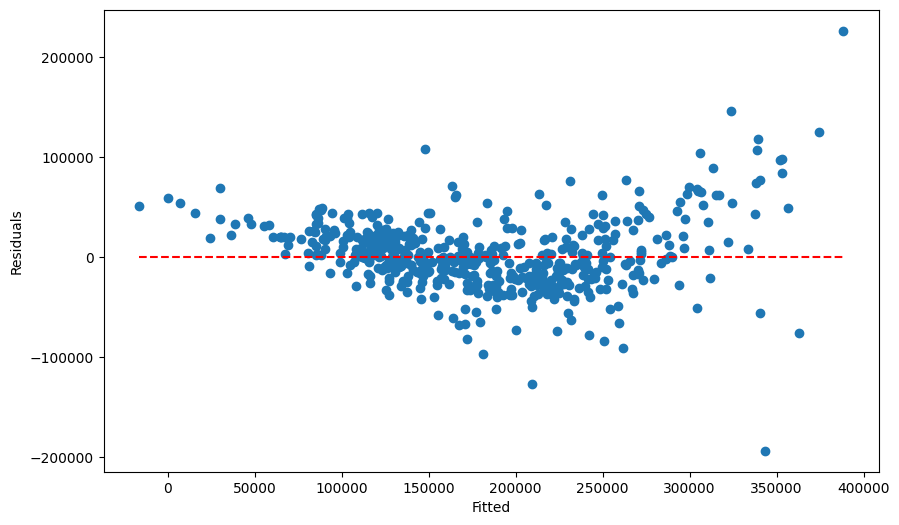

In [53]:
plt.figure(figsize = (10,6))
plt.scatter(y_pred, res)
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.hlines(0, min(y_pred), max(y_pred), colors = 'red', linestyles = 'dashed') ;